# 02 — Modeling & Evaluation: baseline predictive so với các CATE learner

**Sprint 3 · protocol `sprint3-improvement-v1` · run `sprint3-retrospective-confirmation-v1`**

## Tóm tắt

**Câu hỏi nghiên cứu.** Với ngân sách chỉ đủ tiếp cận một phần khách hàng, xếp hạng khách
hàng theo *tác động tăng thêm* của treatment (CATE) có tạo ra nhiều conversion tăng thêm
hơn so với xếp hạng theo *xác suất conversion* (baseline predictive) hay không?

**Thiết kế.** Criteo Uplift v2.1 — randomized incrementality test, 13.979.592 dòng.
Development pool 5.591.836 dòng dùng cho 3-fold cross-fitting OOF ở hai fold seed độc lập;
confirmation 1.397.959 dòng dùng để áp promotion rule **đúng một lần**. Metric chính,
gate và promotion rule được **đăng ký trước** trong `configs/sprint3_improvement_protocol.json`.

**Kết quả.** 12 candidate được screening, 6 vào finalist, 9 model/ensemble được chấm trên
confirmation. Trên metric chính `policy_area_dr`, baseline **Response đứng đầu ở cả hai
fold seed OOF và trên confirmation**. Không challenger nào đạt promotion rule.

**Phát hiện phương pháp luận.** Qini và `policy_area_dr` **xếp hạng ngược nhau**: bốn model
có Qini cao hơn Response nhưng `policy_area_dr` thấp hơn. Nếu Qini vẫn là metric chính như
Sprint 1–2, kết luận đã đảo chiều. Việc đăng ký trước metric hierarchy là thứ duy nhất
ngăn được lựa chọn hậu nghiệm ở đây.

**Kết luận.** Giữ champion Response. Đây là một kết quả âm tính được báo cáo đầy đủ, không
phải một cải thiện.

---

## Phạm vi của notebook này

Notebook **đọc lại artifact đã đóng băng** trong `output/`, không huấn luyện lại model.
Việc huấn luyện nằm ở `scripts/run_oof_experiment.py` và `scripts/run_sprint3_confirmation.py`;
tách trình bày khỏi tính toán là để mọi con số trong notebook truy được về đúng một run có
`run_id`, `commit_sha` và hash split cố định. Notebook chạy trong vài giây và không cần
dữ liệu gốc 13,98 triệu dòng.

Notebook trước: [`01_eda_criteo.ipynb`](01_eda_criteo.ipynb) — audit dữ liệu và balance.

## 1. Thiết lập và xuất xứ (provenance)

Mọi bảng dưới đây đến từ một run duy nhất. Cell này in ra định danh của run và hash của
các split để kết quả truy ngược được; nếu hash development của hai fold seed lệch nhau thì
so sánh giữa chúng vô nghĩa, nên đó là một assertion chứ không phải một dòng log.

In [1]:
import sys, pathlib, json

sys.path.append(str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd

from src.paths import OUTPUT_DIR

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

SPRINT3 = OUTPUT_DIR / "sprint3"
IMPROVE = OUTPUT_DIR / "improvement"

protocol = json.loads((pathlib.Path.cwd().parent / "configs" / "sprint3_improvement_protocol.json").read_text(encoding="utf-8"))
manifest = json.loads((SPRINT3 / "protocol_manifest.json").read_text(encoding="utf-8"))
oof_manifest_101 = json.loads((IMPROVE / "finalist" / "run_manifest.json").read_text(encoding="utf-8"))
oof_manifest_202 = json.loads((IMPROVE / "finalist_seed202" / "run_manifest.json").read_text(encoding="utf-8"))

print("protocol_id        :", manifest["protocol_id"])
print("run_id             :", manifest["run_id"])
print("evidence_class     :", manifest["evidence_class"])
print("development rows   :", f"{manifest['development_rows']:,}")
print("confirmation rows  :", f"{manifest['confirmation_rows']:,}")
print("development hash   :", manifest["development_index_sha256"][:16], "...")
print("confirmation hash  :", manifest["confirmation_index_sha256"][:16], "...")
print("propensity (fixed) :", round(manifest["propensity"], 6))
print("bootstrap draws    :", manifest["n_boot"], "(confirmation) /", oof_manifest_101["n_boot"], "(OOF)")

assert oof_manifest_101["development_index_sha256"] == oof_manifest_202["development_index_sha256"], \
    "Hai fold seed chay tren development pool khac nhau — khong so sanh duoc."
assert oof_manifest_101["fold_seed"] == 101 and oof_manifest_202["fold_seed"] == 202
print("\nHai fold seed dung chung development pool — hash khop.")

protocol_id        : sprint3-improvement-v1
run_id             : sprint3-retrospective-confirmation-v1
evidence_class     : retrospective_confirmation
development rows   : 5,591,836
confirmation rows  : 1,397,959
development hash   : 8ff1ffcde973cb58 ...
confirmation hash  : 6d846e155171a87d ...
propensity (fixed) : 0.85
bootstrap draws    : 500 (confirmation) / 200 (OOF)

Hai fold seed dung chung development pool — hash khop.


`evidence_class = retrospective_confirmation` là một tuyên bố có chủ ý và cần đọc kỹ: tập
confirmation này **đã được quan sát và báo cáo ở Sprint 2**. Nó không phải prospective
unseen test. Điều đó không làm hỏng so sánh giữa các model — mọi model đều chấm trên cùng
tập, và không model nào được tinh chỉnh theo tập này — nhưng nó hạ mức chứng cứ và được
ghi vào manifest thay vì giấu đi.

In [2]:
env = pd.read_csv(IMPROVE / "finalist" / "oof_metrics.csv", nrows=1)
env_cols = ["python_version", "numpy_version", "pandas_version", "sklearn_version", "lightgbm_version", "econml_version", "commit_sha"]
print("Moi truong da ghi lai cung ket qua:")
for c in env_cols:
    print(f"  {c:20s} {env[c].iloc[0]}")

Moi truong da ghi lai cung ket qua:
  python_version       3.12.10
  numpy_version        2.4.6
  pandas_version       2.3.3
  sklearn_version      1.6.1
  lightgbm_version     4.7.0
  econml_version       0.16.0
  commit_sha           d0069be719ebfe219416caa3c9d587432aadf14b


## 2. Estimand và nhận dạng

Ký hiệu potential outcomes (Neyman–Rubin): mỗi khách hàng $i$ có hai kết quả tiềm năng
$Y_i(1)$ nếu được treatment và $Y_i(0)$ nếu không. Đại lượng cần ước lượng là **CATE**:

$$\tau(x) = \mathbb{E}\!\left[\, Y_i(1) - Y_i(0) \;\middle|\; X_i = x \,\right]$$

**Nhận dạng.** Criteo v2.1 là randomized incrementality test, nên $T \perp (Y(1), Y(0)) \mid X$
đúng *theo thiết kế*, không phải theo giả định. Propensity là hằng số thiết kế
$e = P(T=1) \approx 0{,}85$; notebook `01` đã kiểm tra bằng propensity AUC $= 0{,}5098$ và
$\max|\text{SMD}| = 0{,}049$. Đây là lý do dự án dùng dataset này thay vì dữ liệu quan sát:
không phải xử lý confounding, nên mọi khác biệt giữa các model đều quy về chất lượng ước
lượng chứ không phải về giả định nhận dạng.

**Vấn đề cơ bản của suy luận nhân quả** (Holland, 1986). Với mỗi $i$ ta chỉ quan sát được
**một** trong hai $Y_i(1), Y_i(0)$ — không bao giờ cả hai. Do đó $\tau(x)$ **không có nhãn
ground truth ở cấp cá nhân**, và mọi metric kiểu accuracy / AUC / RMSE-trên-uplift đều
không tính được. Đây là khác biệt bản chất so với supervised learning, không phải một
thiếu sót của pipeline. Đánh giá bắt buộc phải chuyển sang:

1. **Metric xếp hạng theo nhóm** — Qini, AUUC, AUTOC/RATE: so sánh outcome giữa nhánh
   treatment và control *trong từng phân vị của điểm số*, không cần nhãn cá nhân.
2. **Offline policy value** — chấm trực tiếp thứ ta thực sự quan tâm: nếu target theo
   điểm số này ở ngân sách $b$, giá trị tăng thêm trên mỗi khách hàng là bao nhiêu.

Dự án chọn (2) làm metric chính. Lý do ở mục 4.

## 3. Giao thức đăng ký trước

Metric chính, gate và promotion rule được ghi vào `configs/sprint3_improvement_protocol.json`
với `registered_utc` **trước** khi chạy confirmation. Đây là biện pháp chống lựa chọn hậu
nghiệm: khi có 9 model × 8 metric, luôn tồn tại ít nhất một cặp cho ra kết luận mong muốn.

In [3]:
print("registered_utc :", protocol["registered_utc"])
print("metric chinh   :", protocol["metrics"]["primary"])
print("dinh nghia     :", protocol["metrics"]["primary_definition"])
print("budget grid    :", protocol["metrics"]["primary_budget_grid"])
print("suy luan       :", protocol["metrics"]["inference"])
print("\nPromotion rule — challenger chi duoc promote khi thoa DONG THOI:")
for k, v in protocol["promotion_rule"].items():
    if k.startswith("condition"):
        print(f"  {k}: {v}")
print("  fallback  :", protocol["promotion_rule"]["fallback"])
print("\nEarly-stop tu dong:")
for k, v in protocol["early_stop"].items():
    print(f"  {k}: {v}")

registered_utc : 2026-08-05T00:00:00+00:00
metric chinh   : policy_area_dr
dinh nghia     : trapezoid mean cua DR gross policy value per customer tren dai budget, chia do rong dai
budget grid    : [0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
suy luan       : paired percentile bootstrap tren cung OOF rows, n_boot mac dinh 500

Promotion rule — challenger chi duoc promote khi thoa DONG THOI:
  condition_1: policy_area_dr OOF cua challenger > Response o ca hai fold seed
  condition_2: point estimate tren retrospective confirmation cung dau
  condition_3: paired 95% CI cua chenh lech policy_area_dr co lower bound > 0
  condition_4: khong regression ve runtime gate, calibration hoac guardrail
  fallback  : giu Response va phat hanh challenger kem CI

Early-stop tu dong:
  constant_score_unique_threshold: 10
  non_finite_score: True
  dominated_at_every_budget_5_to_20: True
  resource_gate_exceeded: True


## 4. Dữ liệu, phân tách và công suất thống kê

Ba tầng dữ liệu tách rời, hash cố định. Điều đáng chú ý về mặt thống kê không phải là số
dòng — mà là **số conversion ở nhánh control**.

In [4]:
arms = oof_manifest_101["arm_counts"]
splits = pd.DataFrame(
    [
        {"Tap": "Development (OOF)", "Rows": manifest["development_rows"], "Vai tro": "cross-fitting, chon shortlist, hoc ensemble weights"},
        {"Tap": "Retrospective confirmation", "Rows": manifest["confirmation_rows"], "Vai tro": "ap promotion rule dung mot lan"},
        {"Tap": "Final test Sprint 1", "Rows": 2_096_940, "Vai tro": "bang chung lich su, khong tai su dung"},
    ]
)
display(splits.style.format({"Rows": "{:,.0f}"}).hide(axis="index"))

print("Development pool — cau truc nhanh:")
print(f"  treated              : {arms['n_treated']:,}   ({arms['n_treated']/arms['n_rows']:.1%})")
print(f"  control              : {arms['n_control']:,}   ({arms['n_control']/arms['n_rows']:.1%})")
print(f"  conversion | treated : {arms['n_conversion_treated']:,}")
print(f"  conversion | control : {arms['n_conversion_control']:,}   <-- rang buoc chi phoi")
print(f"  conversion rate      : {(arms['n_conversion_treated']+arms['n_conversion_control'])/arms['n_rows']:.4%}")

Tap,Rows,Vai tro
Development (OOF),"5,591,836","cross-fitting, chon shortlist, hoc ensemble weights"
Retrospective confirmation,"1,397,959",ap promotion rule dung mot lan
Final test Sprint 1,"2,096,940","bang chung lich su, khong tai su dung"


Development pool — cau truc nhanh:
  treated              : 4,753,061   (85.0%)
  control              : 838,775   (15.0%)
  conversion | treated : 14,684
  conversion | control : 1,625   <-- rang buoc chi phoi
  conversion rate      : 0.2917%


**Ràng buộc chi phối toàn bộ Sprint 3 là 1.625 conversion ở nhánh control.** Trên 5,59
triệu dòng, mọi ước lượng uplift đều là hiệu của hai tỉ lệ nhỏ, và độ rộng của khoảng tin
cậy bị chặn bởi con số 1.625 này chứ không phải bởi 5,59 triệu. Điều này giải thích trước
kết quả ở mục 7: các paired CI rộng, và việc "không đủ bằng chứng để promote" là hệ quả
của công suất thống kê chứ không nhất thiết là bằng chứng rằng các challenger vô dụng.
Phân biệt hai điều đó là bắt buộc — xem mục 10.

Tỉ lệ conversion 0,29% cũng là lý do các candidate dùng undersampling có hiệu chỉnh xác
suất (`UndersamplingCorrectedProbabilityRegressor`, theo Nyberg et al., PMLR 2021): huấn
luyện trên mẫu cân bằng hơn rồi hiệu chỉnh ngược về thang xác suất gốc, thay vì để
LightGBM học trên tín hiệu 0,29%.

## 5. Họ mô hình: baseline và các challenger

**Baseline ở đây chính là mô hình predictive truyền thống.** `Response` xếp hạng khách hàng
theo $\hat{P}(Y=1 \mid X)$ — đúng thứ một pipeline data science thông thường sẽ tạo ra khi
được giao bài toán "chọn ai để target". Toàn bộ Sprint 3 là phép kiểm định giả thuyết
*các phương pháp causal có đánh bại cách làm này không*, nên `Response` không phải một
straw man mà là đối thủ chính.

In [5]:
oof101 = pd.read_csv(IMPROVE / "finalist" / "oof_metrics.csv")
oof202 = pd.read_csv(IMPROVE / "finalist_seed202" / "oof_metrics.csv")

fam = (
    oof101[["candidate", "candidate_family", "config_json", "fit_seconds"]]
    .assign(params=lambda d: d["config_json"].map(lambda s: json.dumps(json.loads(s)["params"], ensure_ascii=False)))
    .drop(columns="config_json")
    .rename(columns={"candidate": "Model", "candidate_family": "Ho", "params": "Tham so", "fit_seconds": "Fit (giay)"})
    .sort_values("Fit (giay)")
)
display(fam.style.format({"Fit (giay)": "{:.1f}"}).hide(axis="index"))

Model,Ho,Fit (giay),Tham so
S-Under7,s_learner,10.8,"{""outcome"": ""classifier"", ""under"": 7.0}"
X-Renormalized,x_learner,33.1,"{""outcome"": ""classifier"", ""propensity"": ""fixed"", ""under"": 7.0}"
Response,response,59.7,{}
Rank-K2,rank_learner,638.2,"{""cv"": 3, ""kappa_scale"": 2.0}"
Rank-K05,rank_learner,638.3,"{""cv"": 3, ""kappa_scale"": 0.5}"
Rank-K1,rank_learner,642.8,"{""cv"": 3, ""kappa_scale"": 1.0}"


| Model | Bản chất | Nguồn |
|---|---|---|
| **Response** | baseline predictive: xếp theo $\hat{P}(Y=1\mid X)$, không ước lượng $\tau$ | — |
| **S-Under7** | S-Learner: một model chung, treatment là một feature; undersampling $k=7$ | Künzel et al., PNAS 2019 |
| **X-Renormalized** | X-Learner với propensity cố định, chuẩn hoá lại theo tỉ lệ undersampling | Künzel et al., PNAS 2019 |
| **Rank-K05/K1/K2** | Rank-Learner: tối ưu trực tiếp *thứ hạng* của $\tau$ bằng orthogonal loss | ICLR 2026, arXiv 2602.03517 |
| **Ensemble-QAgg** | causal Q-aggregation trên development OOF | Lan & Syrgkanis, AISTATS 2024 |
| **Ensemble-BestSingle** | chọn một model theo DR risk | — |
| **Ensemble-RankAverage** | trung bình thứ hạng của các thành viên | — |

Ba model đầu nằm trong nhóm **meta-learner**: dùng model dự đoán bất kỳ (ở đây LightGBM)
làm nuisance rồi ghép lại thành ước lượng $\tau$. Rank-Learner thuộc nhóm khác — nó bỏ qua
việc ước lượng $\tau$ chính xác và tối ưu thẳng thứ hạng, vốn là thứ duy nhất mà một
policy top-k thực sự dùng.

## 6. Các metric và lý do chọn metric chính

**`policy_area_dr` (metric chính).** Với policy nhị phân $\pi_b$ = "target top $b$ theo
điểm số", giá trị policy được chấm bằng tín hiệu **doubly robust**:

$$\hat{V}(\pi) = \frac{1}{n}\sum_i \left[ \mu_1(X_i) - \mu_0(X_i) \right]\pi(X_i)
+ \frac{T_i - e}{e(1-e)}\left(Y_i - \mu_{T_i}(X_i)\right)\pi(X_i)$$

`policy_area_dr` là trung bình hình thang của $\hat{V}(\pi_b)$ trên dải budget
$b \in [0{,}01;\ 0{,}30]$, chia cho độ rộng dải.

Ba lý do chọn nó làm metric chính, cả ba đều đăng ký trước:

1. **Nó là đại lượng quyết định.** Sản phẩm phát hành là một policy top-k dưới ràng buộc
   ngân sách, nên metric nên chấm chính policy đó, không chấm một tính chất gián tiếp của
   điểm số. Khung giá trị/regret: Athey & Wager, Econometrica 2021.
2. **Doubly robust.** Ước lượng đúng nếu *hoặc* outcome model $\mu_t$ đúng *hoặc* propensity
   đúng. Ở đây propensity là hằng số thiết kế và biết chính xác, nên vế thứ hai luôn đúng —
   tín hiệu chấm điểm không bị lệch vì nuisance model kém.
3. **Ổn định hơn Qini.** Nghiên cứu 2026 về độ ổn định metric (arXiv 2603.20775) báo Qini
   kém ổn định hơn AUTOC/policy value ở outcome hiếm. Với 1.625 conversion control, đây
   không phải mối lo lý thuyết.

**Metric phụ.** `autoc_dr` (AUTOC/RATE — Yadlowsky, Fleming, Shah, Brunskill & Wager, JASA
2025), `qini_score`, `auuc_score`, `uplift_calibration_error`, `doubly_robust_risk`, và các
biến thể outcome-adjusted theo Bokelmann & Lessmann, EJOR 2024.

**Suy luận thống kê.** Paired percentile bootstrap trên cùng các dòng OOF — cặp đôi là
điểm mấu chốt: hai model chấm trên *cùng* khách hàng, nên phương sai chung bị khử và CI
của *chênh lệch* hẹp hơn nhiều so với hiệu của hai CI riêng lẻ.

## 7. Quy ước trình bày

Bảng màu gán **cố định theo model**, không theo thứ hạng — cùng một model giữ nguyên màu ở
mọi biểu đồ, để việc đổi thứ tự giữa các hình không đọc thành đổi đối tượng. Bảng màu đã
qua kiểm tra tách biệt cho thị giác màu bất thường (deutan/protan/tritan).

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})

# Mau gan theo thuc the, co dinh xuyen suot notebook.
CHAMPION = "#2a78d6"   # Response — baseline predictive
C_QAGG   = "#eb6834"   # Ensemble-QAgg
C_SUND   = "#1baf7a"   # S-Under7
C_XREN   = "#4a3aa7"   # X-Renormalized
MUTED    = "#898781"   # cac model con lai
REF      = "#c3c2b7"   # duong tham chieu / comparator ngau nhien

MODEL_COLOR = {
    "Response": CHAMPION,
    "Ensemble-QAgg": C_QAGG,
    "S-Under7": C_SUND,
    "X-Renormalized": C_XREN,
}
color_of = lambda m: MODEL_COLOR.get(m, MUTED)

INK, INK2 = "#0b0b0b", "#52514e"
print("Bang mau da co dinh theo model.")

Bang mau da co dinh theo model.


## 8. Kết quả 1 — Development OOF, hai fold seed độc lập

Điều kiện 1 của promotion rule đòi challenger phải thắng Response **ở cả hai fold seed**.
Hai fold seed là hai cách chia 3-fold khác nhau trên *cùng* development pool; một model
thắng ở seed này mà thua ở seed kia thì chênh lệch đó là nhiễu của cách chia, không phải
tín hiệu.

In [7]:
keep = ["candidate", "fold_seed", "policy_area_dr", "autoc_dr", "qini_score", "doubly_robust_risk"]
oof = pd.concat([oof101[keep], oof202[keep]], ignore_index=True)

pivot = (
    oof.pivot(index="candidate", columns="fold_seed", values="policy_area_dr")
    .rename(columns={101: "seed 101", 202: "seed 202"})
    .assign(**{"trung binh": lambda d: d.mean(axis=1)})
    .sort_values("trung binh", ascending=False)
)
pivot["thang Response"] = [
    int(pivot.loc[m, "seed 101"] > pivot.loc["Response", "seed 101"])
    + int(pivot.loc[m, "seed 202"] > pivot.loc["Response", "seed 202"])
    for m in pivot.index
]
display(
    pivot.style.format({"seed 101": "{:.6f}", "seed 202": "{:.6f}", "trung binh": "{:.6f}"})
    .set_caption("policy_area_dr tren development OOF (cao hon = tot hon)")
)

winners = pivot.drop(index="Response")
print("So challenger thang Response o CA HAI fold seed:", int((winners["thang Response"] == 2).sum()))

fold_seed,seed 101,seed 202,trung binh,thang Response
candidate,,,,
Response,0.000852,0.000870,0.000861,0
X-Renormalized,0.000826,0.000844,0.000835,0
S-Under7,0.000829,0.000799,0.000814,0
Rank-K2,0.000793,0.000802,0.000798,0
Rank-K1,0.000771,0.000802,0.000787,0
Rank-K05,0.000747,0.000795,0.000771,0


So challenger thang Response o CA HAI fold seed: 0


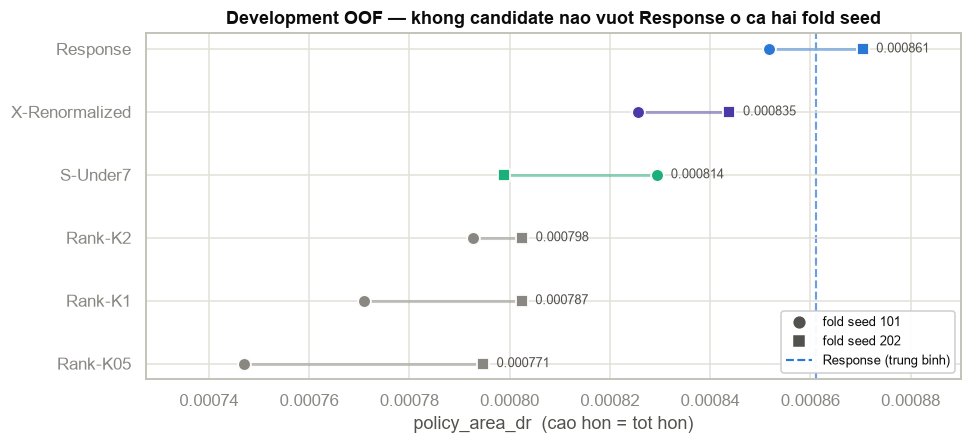

In [8]:
order = pivot.index.tolist()[::-1]
y = np.arange(len(order))

fig, ax = plt.subplots(figsize=(9, 4.2))
for i, m in enumerate(order):
    v101, v202 = pivot.loc[m, "seed 101"], pivot.loc[m, "seed 202"]
    ax.plot([v101, v202], [i, i], color=color_of(m), lw=2, alpha=0.45, solid_capstyle="round", zorder=1)
    ax.scatter(v101, i, s=70, color=color_of(m), marker="o", zorder=3, edgecolor="#fcfcfb", linewidth=1.2)
    ax.scatter(v202, i, s=70, color=color_of(m), marker="s", zorder=3, edgecolor="#fcfcfb", linewidth=1.2)

ax.axvline(pivot.loc["Response", "trung binh"], color=CHAMPION, ls="--", lw=1.4, alpha=0.7, zorder=0)
ax.set_yticks(y, order)
ax.set_xlabel("policy_area_dr  (cao hon = tot hon)")
ax.set_title("Development OOF — khong candidate nao vuot Response o ca hai fold seed")
ax.margins(x=0.16)

for i, m in enumerate(order):
    ax.annotate(f"{pivot.loc[m, 'trung binh']:.6f}", (max(pivot.loc[m, 'seed 101'], pivot.loc[m, 'seed 202']), i),
                xytext=(9, 0), textcoords="offset points", va="center", fontsize=8.5, color=INK2)

from matplotlib.lines import Line2D
ax.legend(
    handles=[
        Line2D([], [], marker="o", ls="", color=INK2, markersize=7, label="fold seed 101"),
        Line2D([], [], marker="s", ls="", color=INK2, markersize=7, label="fold seed 202"),
        Line2D([], [], ls="--", color=CHAMPION, lw=1.4, label="Response (trung binh)"),
    ],
    loc="lower right", frameon=True, framealpha=0.95, fontsize=8.5,
)
plt.tight_layout()
plt.show()

Response đứng đầu ở cả hai fold seed, và khoảng cách giữa hai seed của cùng một model
(chiều dài đoạn nối) nhỏ hơn khoảng cách giữa các model — nghĩa là xếp hạng ổn định trước
cách chia fold, không phải kết quả của một lần chia may mắn. **Điều kiện 1 của promotion
rule hỏng với toàn bộ 5 challenger ngay ở bước này.**

Ba biến thể Rank-Learner tụt hạng rõ rệt dù tối ưu đúng thứ hạng — với 1.625 conversion
control, orthogonal ranking loss không đủ tín hiệu để vượt một baseline đơn giản. Đây là
quan sát nhất quán với các benchmark deep uplift (arXiv 2406.00335) rằng phương pháp phức
tạp thường không tái lập được lợi thế trên dữ liệu outcome hiếm.

## 9. Kết quả 2 — Retrospective confirmation

Áp đúng một lần trên 1.397.959 dòng chưa dùng để chọn model.

In [9]:
conf = pd.read_csv(SPRINT3 / "confirmation_metrics.csv")
tbl = (
    conf[["model", "policy_area_dr", "autoc_dr", "qini_score", "auuc_score", "doubly_robust_risk", "is_cate_scale"]]
    .sort_values("policy_area_dr", ascending=False)
    .reset_index(drop=True)
)
display(
    tbl.style.format({c: "{:.6f}" for c in ["policy_area_dr", "autoc_dr", "qini_score", "auuc_score", "doubly_robust_risk"]}, na_rep="—")
    .set_caption("Confirmation — sap xep theo metric chinh policy_area_dr")
    .hide(axis="index")
)

model,policy_area_dr,autoc_dr,qini_score,auuc_score,doubly_robust_risk,is_cate_scale
Response,0.000912,0.003823,0.192989,0.006244,—,False
Ensemble-QAgg,0.000911,0.003271,0.209845,0.006780,0.014820,True
Ensemble-RankAverage,0.000908,0.003332,0.195022,0.006304,—,False
S-Under7,0.000896,0.003116,0.205904,0.006658,0.014820,True
X-Renormalized,0.000890,0.003283,0.201812,0.006521,0.014820,True
Ensemble-BestSingle,0.000890,0.003283,0.201812,0.006521,0.014820,True
Rank-K2,0.000862,0.002454,0.184993,0.005983,—,False
Rank-K1,0.000852,0.002400,0.185657,0.006005,—,False
Rank-K05,0.000848,0.002388,0.186454,0.006032,—,False


Hai chi tiết cần đọc kỹ trước khi diễn giải bảng:

- `doubly_robust_risk` và `uplift_calibration_error` **trống với Response, Rank-K\* và
  Ensemble-RankAverage**. Không phải thiếu số: các model này trả về *điểm xếp hạng*, không
  phải ước lượng $\tau$ trên thang CATE (`is_cate_scale = False`), nên hỏi "sai số hiệu
  chỉnh của chúng bằng bao nhiêu" là câu hỏi không có nghĩa. Ghi trống đúng hơn là điền 0.
- **`Ensemble-BestSingle` trùng khít `X-Renormalized`** ở mọi cột. Đúng như thiết kế:
  best-single theo DR risk đã chọn X-Renormalized với trọng số 1,0. Nó không phải một
  model độc lập thứ chín và không được đếm như một bằng chứng riêng.

## 10. Kết quả 3 — Bất đồng metric: phát hiện quan trọng nhất

Nếu đọc bảng trên theo cột `qini_score` thay vì `policy_area_dr`, thứ hạng đảo lại.

findfont: Failed to find font weight semibold, now using 700.


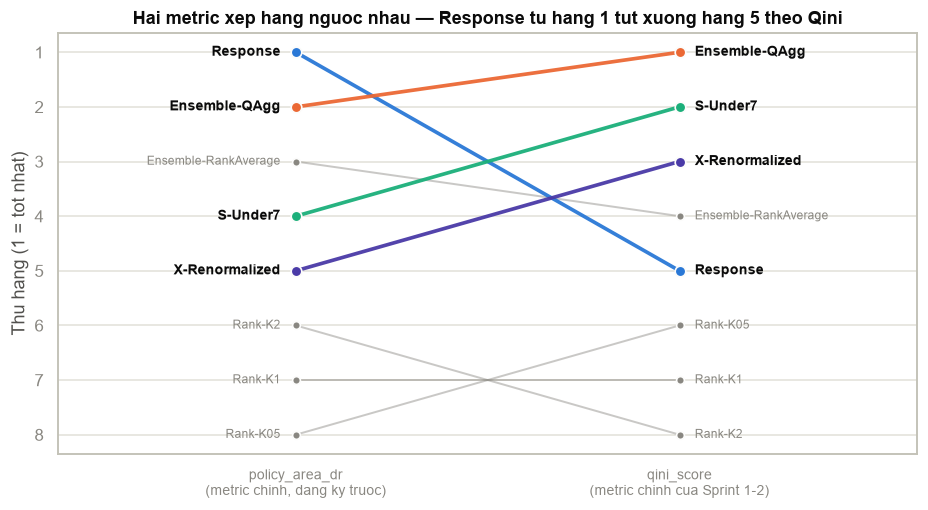

In [10]:
d = conf[conf["model"] != "Ensemble-BestSingle"].copy()
d["rank_policy"] = d["policy_area_dr"].rank(ascending=False).astype(int)
d["rank_qini"] = d["qini_score"].rank(ascending=False).astype(int)
d = d.sort_values("rank_policy")

fig, ax = plt.subplots(figsize=(8.6, 4.8))
for _, r in d.iterrows():
    m = r["model"]
    c = color_of(m)
    highlighted = m in MODEL_COLOR
    ax.plot([0, 1], [r["rank_policy"], r["rank_qini"]], color=c, lw=2.4 if highlighted else 1.3,
            alpha=0.95 if highlighted else 0.45, solid_capstyle="round", zorder=3 if highlighted else 1)
    ax.scatter([0, 1], [r["rank_policy"], r["rank_qini"]], s=48 if highlighted else 26, color=c,
               zorder=4 if highlighted else 2, edgecolor="#fcfcfb", linewidth=1.1)
    ax.annotate(m, (0, r["rank_policy"]), xytext=(-10, 0), textcoords="offset points",
                ha="right", va="center", fontsize=9 if highlighted else 8,
                color=INK if highlighted else MUTED, weight="semibold" if highlighted else "normal")
    ax.annotate(m, (1, r["rank_qini"]), xytext=(10, 0), textcoords="offset points",
                ha="left", va="center", fontsize=9 if highlighted else 8,
                color=INK if highlighted else MUTED, weight="semibold" if highlighted else "normal")

ax.set_xlim(-0.62, 1.62)
ax.invert_yaxis()
ax.set_xticks([0, 1], ["policy_area_dr\n(metric chinh, dang ky truoc)", "qini_score\n(metric chinh cua Sprint 1-2)"], fontsize=9)
ax.set_ylabel("Thu hang (1 = tot nhat)")
ax.set_yticks(range(1, len(d) + 1))
ax.set_title("Hai metric xep hang nguoc nhau — Response tu hang 1 tut xuong hang 5 theo Qini")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

In [11]:
flip = conf[conf["qini_score"] > conf.loc[conf["model"] == "Response", "qini_score"].iloc[0]]
resp = conf[conf["model"] == "Response"].iloc[0]
print(f"Response          policy_area_dr={resp['policy_area_dr']:.6f}   qini={resp['qini_score']:.6f}")
print("\nCac model co Qini CAO HON Response nhung policy_area_dr THAP HON:")
for _, r in flip.sort_values("qini_score", ascending=False).iterrows():
    print(f"  {r['model']:22s} qini={r['qini_score']:.6f} (+{r['qini_score']-resp['qini_score']:.6f})"
          f"   policy_area_dr={r['policy_area_dr']:.6f} ({r['policy_area_dr']-resp['policy_area_dr']:+.6f})")

Response          policy_area_dr=0.000912   qini=0.192989

Cac model co Qini CAO HON Response nhung policy_area_dr THAP HON:
  Ensemble-QAgg          qini=0.209845 (+0.016855)   policy_area_dr=0.000911 (-0.000001)
  S-Under7               qini=0.205904 (+0.012914)   policy_area_dr=0.000896 (-0.000017)
  X-Renormalized         qini=0.201812 (+0.008822)   policy_area_dr=0.000890 (-0.000023)
  Ensemble-BestSingle    qini=0.201812 (+0.008822)   policy_area_dr=0.000890 (-0.000023)
  Ensemble-RankAverage   qini=0.195022 (+0.002033)   policy_area_dr=0.000908 (-0.000005)


**Đây là tình huống mà việc đăng ký trước metric được thiết kế để xử lý.** Bốn model có
Qini cao hơn Response; nếu Qini vẫn là metric chính như Sprint 1–2, ít nhất một challenger
đã được promote. Vì metric chính đã được chốt là `policy_area_dr` *trước* khi nhìn kết quả,
không có chỗ để chọn metric có lợi sau khi thấy số.

Vì sao hai metric lệch nhau? Qini tích luỹ uplift trên *toàn bộ* dải từ 0% đến 100% dân số,
còn `policy_area_dr` chỉ tính trên dải budget 1–30% — đúng vùng mà quyết định thực sự diễn
ra. Một model xếp hạng tốt ở phần đuôi (70–100%) được Qini thưởng nhưng hoàn toàn vô ích
cho một chiến dịch chỉ tiếp cận được 10% khách hàng. AUTOC — vốn đánh trọng số cao hơn cho
phần đầu — xếp hạng đồng thuận với `policy_area_dr`, không đồng thuận với Qini.

## 11. Kết quả 4 — Paired bootstrap: chênh lệch có tách khỏi 0 không?

Chênh lệch điểm ước lượng không đủ để kết luận. Điều kiện 3 của promotion rule đòi **cận
dưới của paired 95% CI phải dương**. 500 lần lấy mẫu bootstrap trên cùng các dòng
confirmation, ghép cặp theo khách hàng.

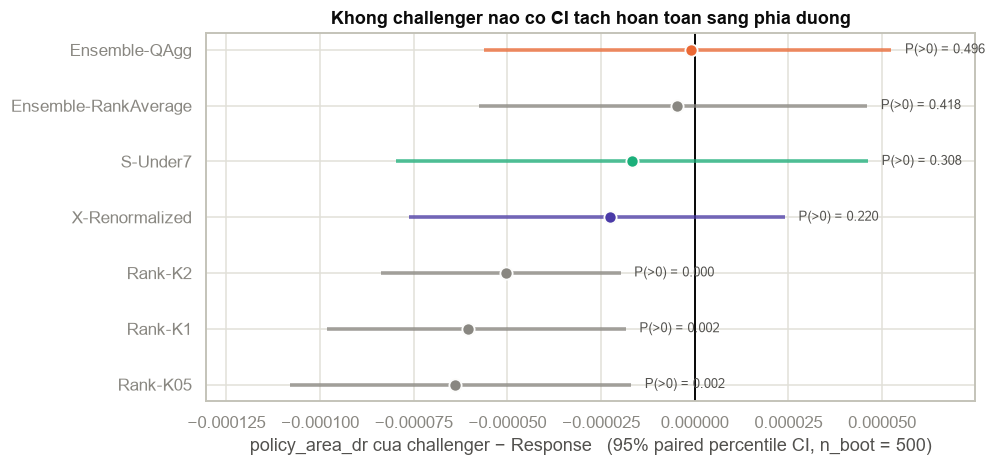

In [12]:
pc = pd.read_csv(SPRINT3 / "paired_comparisons.csv")
vs_resp = pc[(pc["model_b"] == "Response") & (pc["model_a"] != "Ensemble-BestSingle")].copy()
vs_resp = vs_resp.sort_values("policy_area_difference")

fig, ax = plt.subplots(figsize=(9.2, 4.4))
yy = np.arange(len(vs_resp))
for i, (_, r) in enumerate(vs_resp.iterrows()):
    c = color_of(r["model_a"])
    ax.hlines(i, r["policy_area_ci_low"], r["policy_area_ci_high"], color=c, lw=2.4, alpha=0.75, zorder=2)
    ax.scatter(r["policy_area_difference"], i, s=64, color=c, zorder=3, edgecolor="#fcfcfb", linewidth=1.2)

ax.axvline(0, color=INK, lw=1.3, zorder=1)
ax.set_yticks(yy, vs_resp["model_a"].tolist())
ax.set_xlabel("policy_area_dr cua challenger − Response   (95% paired percentile CI, n_boot = 500)")
ax.set_title("Khong challenger nao co CI tach hoan toan sang phia duong")
ax.margins(x=0.14)

for i, (_, r) in enumerate(vs_resp.iterrows()):
    ax.annotate(f"P(>0) = {r['policy_area_probability_positive']:.3f}",
                (r["policy_area_ci_high"], i), xytext=(9, 0), textcoords="offset points",
                va="center", fontsize=8.5, color=INK2)

ax.annotate("Response tot hon", (0, len(vs_resp) - 0.35), xytext=(-8, 0), textcoords="offset points",
            ha="right", fontsize=9, color=INK2, style="italic")
ax.annotate("challenger tot hon", (0, len(vs_resp) - 0.35), xytext=(8, 0), textcoords="offset points",
            ha="left", fontsize=9, color=INK2, style="italic")
plt.tight_layout()
plt.show()

Đọc hình này theo hai tầng:

- **Ba challenger nằm hoàn toàn bên trái số 0** (Rank-K05, Rank-K1, Rank-K2): CI không chứa
  0, chênh lệch âm. Đây là bằng chứng dương rằng chúng **thực sự kém hơn** Response, không
  phải "chưa kết luận được".
- **Bốn challenger còn lại có CI cắt qua 0.** Ensemble-QAgg gần như trùng Response
  ($\Delta = -1{,}1\times10^{-6}$, $P(>0) = 0{,}496$ — gần đúng một phép tung đồng xu). Đây
  là **chưa đủ bằng chứng**, không phải bằng chứng về sự tương đương. Hai điều này khác
  nhau và không được nhập làm một.

Trên metric phụ `autoc_dr`, kết luận **chặt hơn**: CI của mọi challenger đều nằm hoàn toàn
bên trái 0.

In [13]:
sub = vs_resp[["model_a", "autoc_difference", "autoc_ci_low", "autoc_ci_high", "autoc_probability_positive"]].copy()
sub["CI tach khoi 0 (challenger kem hon)"] = sub["autoc_ci_high"] < 0
display(
    sub.rename(columns={"model_a": "Challenger", "autoc_difference": "delta AUTOC",
                        "autoc_ci_low": "CI thap", "autoc_ci_high": "CI cao",
                        "autoc_probability_positive": "P(>0)"})
    .style.format({"delta AUTOC": "{:.6f}", "CI thap": "{:.6f}", "CI cao": "{:.6f}", "P(>0)": "{:.3f}"})
    .hide(axis="index")
)

Challenger,delta AUTOC,CI thap,CI cao,P(>0),CI tach khoi 0 (challenger kem hon)
Rank-K05,-0.001434,-0.001877,-0.000981,0.000,True
Rank-K1,-0.001423,-0.001856,-0.000975,0.000,True
Rank-K2,-0.001369,-0.001765,-0.000920,0.000,True
X-Renormalized,-0.000540,-0.000962,-0.000108,0.006,True
S-Under7,-0.000707,-0.001250,-0.000164,0.000,True
Ensemble-RankAverage,-0.000491,-0.000901,-0.000046,0.010,True
Ensemble-QAgg,-0.000552,-0.001024,-0.000067,0.006,True


## 12. Kết quả 5 — Đường cong ngân sách–giá trị

Metric chính là diện tích dưới đường cong này trên dải 1–30%. Vẽ ra để kiểm tra rằng kết
luận không phụ thuộc vào một điểm ngân sách cụ thể.

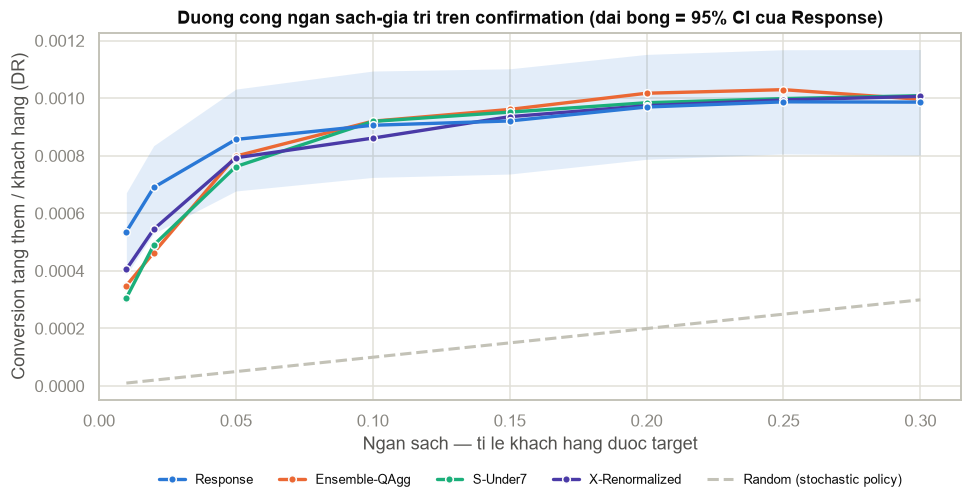

In [14]:
bc = pd.read_csv(SPRINT3 / "policy_budget_curve.csv")
RANDOM = "Expected random (stochastic policy)"
show = ["Response", "Ensemble-QAgg", "S-Under7", "X-Renormalized"]

fig, ax = plt.subplots(figsize=(9, 4.8))
r = bc[bc["model"] == "Response"].sort_values("budget_fraction")
ax.fill_between(r["budget_fraction"], r["ci_low"], r["ci_high"], color=CHAMPION, alpha=0.13, lw=0, zorder=1)

for m in show:
    s = bc[bc["model"] == m].sort_values("budget_fraction")
    ax.plot(s["budget_fraction"], s["gross_value_per_customer"], color=color_of(m), lw=2.2,
            marker="o", markersize=5, markeredgecolor="#fcfcfb", markeredgewidth=1.0,
            zorder=4 if m == "Response" else 3, label=m)

rnd = bc[bc["model"] == RANDOM].sort_values("budget_fraction")
ax.plot(rnd["budget_fraction"], rnd["gross_value_per_customer"], color=REF, lw=2, ls="--",
        zorder=2, label="Random (stochastic policy)")

ax.set_xlabel("Ngan sach — ti le khach hang duoc target")
ax.set_ylabel("Conversion tang them / khach hang (DR)")
ax.set_title("Duong cong ngan sach-gia tri tren confirmation (dai bong = 95% CI cua Response)")
ax.set_xlim(0, 0.315)

# Bon duong hoi tu o phia phai nen direct label se chong nhau — dung legend duoi truc,
# kem bang so ngay sau hinh (quy tac relief cho mau co tuong phan thap).
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=5, frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()

In [15]:
wide = (
    bc[bc["model"].isin(show + [RANDOM])]
    .pivot(index="budget_fraction", columns="model", values="gross_value_per_customer")[show + [RANDOM]]
)
wide.index = [f"{b:.0%}" for b in wide.index]
display(wide.style.format("{:.6f}").set_caption("Gross value / khach hang theo ngan sach (bang so cua hinh tren)"))

be = bc[(bc["model"] == "Response")][["budget_fraction", "gross_value_per_customer", "break_even_contact_cost"]]
print("\nChi phi lien he hoa von cua Response (gia tri 1 conversion = 1 don vi):")
for _, x in be.iterrows():
    print(f"  budget {x['budget_fraction']:>5.0%}  break-even contact cost = {x['break_even_contact_cost']:.5f}")

model,Response,Ensemble-QAgg,S-Under7,X-Renormalized,Expected random (stochastic policy)
1%,0.000536,0.000349,0.000306,0.000405,0.000010
2%,0.000690,0.000463,0.000490,0.000545,0.000020
5%,0.000857,0.000799,0.000762,0.000793,0.000050
10%,0.000906,0.000920,0.000919,0.000861,0.000100
15%,0.000921,0.000961,0.000952,0.000936,0.000150
20%,0.000969,0.001017,0.000984,0.000974,0.000200
25%,0.000987,0.001030,0.000999,0.000994,0.000249
30%,0.000986,0.000996,0.001009,0.001006,0.000299



Chi phi lien he hoa von cua Response (gia tri 1 conversion = 1 don vi):
  budget    1%  break-even contact cost = 0.05361
  budget    2%  break-even contact cost = 0.03449
  budget    5%  break-even contact cost = 0.01713
  budget   10%  break-even contact cost = 0.00906
  budget   15%  break-even contact cost = 0.00614
  budget   20%  break-even contact cost = 0.00485
  budget   25%  break-even contact cost = 0.00395
  budget   30%  break-even contact cost = 0.00329


Bốn model gần như chồng lên nhau ở mọi mức ngân sách, và cả bốn đều tách rõ khỏi đường
Random — nghĩa là **việc xếp hạng có giá trị thật**, chỉ là cách xếp hạng nào thì không
phân biệt được với dữ liệu này. Response giữ vị trí cao nhất hoặc ngang bằng ở toàn dải,
nên kết luận không phải là hiệu ứng của việc chọn riêng mức 10%.

Cột break-even trả lời câu hỏi vận hành: ở ngân sách 10%, chiến dịch hoà vốn khi chi phí
liên hệ một khách hàng bằng 0,00906 lần giá trị một conversion. Ở ngân sách 1% ngưỡng này
nới lên 0,0536 — target hẹp thì chịu được chi phí đơn vị cao hơn nhiều.

## 13. Kết quả 6 — So với các comparator ở kịch bản chính

Kịch bản đăng ký trước: ngân sách 10%, chi phí liên hệ 0,0005, giá trị một conversion 1,0.
So sánh với hai comparator bắt buộc — *không làm gì* và *chọn ngẫu nhiên* — để xác nhận
rằng bài toán có tồn tại lợi ích, trước khi tranh luận model nào tốt hơn.

Kich ban: budget=10%, contact_cost=0.0005, value_per_conversion=1.0, monetary_outcome_available=False


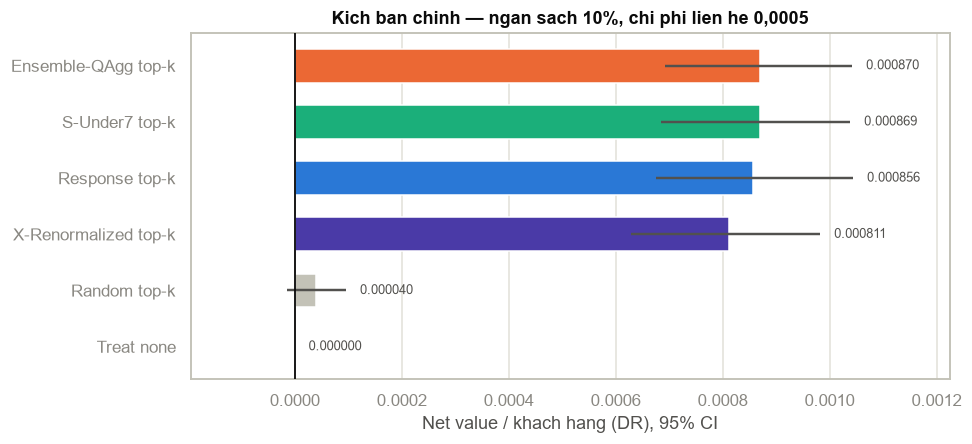

In [16]:
pv = pd.read_csv(SPRINT3 / "policy_value_comparison.csv")
sc = manifest["main_scenario"]
print(f"Kich ban: budget={sc['budget_fraction']:.0%}, contact_cost={sc['contact_cost']}, "
      f"value_per_conversion={sc['value_per_conversion']}, monetary_outcome_available={sc['monetary_outcome_available']}")

keep_pol = ["Treat none", "Random top-k", "Response top-k", "Ensemble-QAgg top-k", "S-Under7 top-k", "X-Renormalized top-k"]
p = pv[pv["policy"].isin(keep_pol)].sort_values("dr_net_scenario_value_per_customer").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4.2))
for i, r in p.iterrows():
    m = r["policy"].replace(" top-k", "")
    c = color_of(m) if m in MODEL_COLOR else REF
    ax.barh(i, r["dr_net_scenario_value_per_customer"], color=c, height=0.6, zorder=2)
    ax.hlines(i, r["dr_ci_low"], r["dr_ci_high"], color=INK2, lw=1.6, zorder=3)
    ax.annotate(f"{r['dr_net_scenario_value_per_customer']:.6f}", (r["dr_ci_high"], i),
                xytext=(9, 0), textcoords="offset points", va="center", fontsize=8.5, color=INK2)

ax.axvline(0, color=INK, lw=1.2, zorder=4)
ax.set_yticks(range(len(p)), p["policy"].tolist())
ax.set_xlabel("Net value / khach hang (DR), 95% CI")
ax.set_title("Kich ban chinh — ngan sach 10%, chi phi lien he 0,0005")
ax.margins(x=0.17)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

Random top-k gần như bằng 0 và CI của nó chứa 0 — đúng như kỳ vọng lý thuyết trong một RCT:
chọn ngẫu nhiên 10% thì lợi ích tăng thêm trên mỗi khách hàng gần bằng ATE nhân tỉ lệ, trừ
đi chi phí, còn lại xấp xỉ 0. Mọi model đều tách rõ khỏi cả *treat none* lẫn *random*. Đó
là kết luận vững nhất của Sprint 3, và nó có giá trị vận hành độc lập với việc model nào
thắng: **targeting có xếp hạng đáng làm; tranh cãi chỉ nằm ở chọn bộ xếp hạng nào.**

Một lưu ý bắt buộc để không đọc sai hình này: tại **riêng** mức ngân sách 10%, điểm ước
lượng của Ensemble-QAgg và S-Under7 nhỉnh hơn Response. Điều đó không mâu thuẫn với kết
luận — metric chính là *diện tích trên toàn dải 1–30%*, không phải một điểm ngân sách, và
paired CI ở mục 11 cho thấy chênh lệch tại đây không tách khỏi 0. Chọn ra mức ngân sách có
lợi nhất sau khi nhìn kết quả chính là loại lựa chọn hậu nghiệm mà protocol đăng ký trước
được lập ra để chặn.

## 14. Áp promotion rule

Rule được áp **đúng một lần**, không lặp lại với biến thể khác.

In [17]:
pd_dec = pd.read_csv(SPRINT3 / "promotion_decision.csv")
cols = {
    "challenger": "Challenger", "oof_seeds_won": "OOF seed thang",
    "condition_1_oof_wins_all_seeds": "DK1 OOF ca 2 seed",
    "condition_2_confirmation_same_sign": "DK2 cung dau",
    "condition_3_paired_ci_lower_bound_positive": "DK3 CI duoi > 0",
    "promoted": "PROMOTED",
}
display(pd_dec[list(cols)].rename(columns=cols).style.hide(axis="index"))
print("So challenger duoc promote:", int(pd_dec["promoted"].sum()), "/", len(pd_dec))
print("Champion sau Sprint 3      :", pd_dec["champion"].iloc[0])

Challenger,OOF seed thang,DK1 OOF ca 2 seed,DK2 cung dau,DK3 CI duoi > 0,PROMOTED
X-Renormalized,0,False,False,False,False
S-Under7,0,False,False,False,False
Rank-K05,0,False,False,False,False
Rank-K1,0,False,False,False,False
Rank-K2,0,False,False,False,False
Ensemble-BestSingle,0,False,False,False,False
Ensemble-QAgg,0,False,False,False,False
Ensemble-RankAverage,0,False,False,False,False


So challenger duoc promote: 0 / 8
Champion sau Sprint 3      : Response


Toàn bộ 8 challenger hỏng ngay điều kiện 1 (`oof_seeds_won = 0`). Điều kiện 2 cũng hỏng vì
mọi chênh lệch trên confirmation đều âm. Fallback của protocol được kích hoạt: **giữ
Response, phát hành các challenger kèm CI** thay vì loại bỏ chúng khỏi hồ sơ.

## 15. Sổ đăng ký thực nghiệm — kể cả các run thất bại

Một điều kiện của tính toàn vẹn khoa học là các run bị dừng sớm cũng phải nằm trong hồ sơ.
`output/improvement/registry.csv` ghi mọi run, kèm lý do dừng.

In [18]:
reg = pd.read_csv(IMPROVE / "registry.csv")
print("Tong so run da dang ky:", len(reg))
print("\nTheo stage/status:")
display(reg.groupby(["status"]).size().rename("so run").to_frame())

if "failure_reason" in reg.columns:
    failed = reg[reg["failure_reason"].notna()][["run_id", "candidate", "fold_seed", "pool_fraction", "failure_reason"]]
    print("\nCac run bi dung som:")
    display(failed.style.hide(axis="index"))

Tong so run da dang ky: 53

Theo stage/status:


,so run
status,
diagnostic,2
failed,2
finalist,12
released,1
retrospective_confirmation,6
screen,18
smoke,12



Cac run bi dung som:


run_id,candidate,fold_seed,pool_fraction,failure_reason
sprint3-improvement-v1-smoke-X-Renormalized,X-Renormalized,101.000000,0.010000,constant_score
sprint3-improvement-v1-smoke-S-Under7,S-Under7,101.000000,0.010000,constant_score
causal-forest-kaggle-0p2,Causal-Forest-kaggle-safe,nan,0.200000,holdout khac final test Sprint 1; khong so voi bang release
causal-forest-kaggle-0p3,Causal-Forest-kaggle-safe,nan,0.300000,holdout khac final test Sprint 1; khong so voi bang release


Ví dụ minh hoạ vì sao điều này quan trọng: ở stage smoke 1%, `X-Renormalized` và `S-Under7`
trả về **điểm số hằng số** — undersampling $k=7$ trên mẫu quá nhỏ khiến
`min_child_samples = 1000` chặn mọi split của LightGBM. Quy tắc early-stop tự động bắt được
và ghi `failure_reason = constant_score`. Nếu chỉ báo cáo các run thành công, hai model này
sẽ trông như chưa bao giờ gặp vấn đề.

## 16. Giới hạn và mối đe dọa đối với tính hợp lệ

Liệt kê đầy đủ, kể cả những điểm làm yếu kết luận.

**1. Công suất thống kê, không phải bằng chứng về sự tương đương.** Với 1.625 conversion ở
nhánh control, các paired CI đủ rộng để chứa những cải thiện có ý nghĩa vận hành. Kết luận
đúng là *"không đủ bằng chứng để promote"*, **không phải** *"các challenger tương đương
Response"*. Ba biến thể Rank-Learner là ngoại lệ — CI của chúng tách hẳn về phía âm, nên ở
đó ta có bằng chứng dương về việc kém hơn.

**2. Confirmation là retrospective, không phải prospective.** Tập này đã được quan sát ở
Sprint 2. Nó không bị dùng để tinh chỉnh challenger nào, nhưng mức chứng cứ vẫn thấp hơn
một unseen test thật sự, và manifest ghi rõ điều đó.

**3. Không có A/B test online.** Mọi giá trị policy đều là *offline estimate* trên dữ liệu
RCT có sẵn. Doubly robust với propensity biết chính xác là điều kiện thuận lợi hiếm có,
nhưng vẫn không thay thế được một thí nghiệm triển khai thật.

**4. Benchmark public, không phải campaign gốc.** Criteo v2.1 được ghép từ nhiều
incrementality test và **subsample không đồng đều** vì lý do riêng tư (xem
`docs/data_cards/CRITEO_V2_1.md`). ATE và Qini ở đây là kết quả *trên benchmark*, không
suy ngược được thành incrementality của campaign thương mại.

**5. Feature ẩn danh.** `f0`–`f11` đã được ẩn danh và chiếu ngẫu nhiên. Không gán được ý
nghĩa kinh doanh cho từng feature, nên notebook này không đưa ra bất kỳ diễn giải nào về
"khách hàng loại nào phản ứng mạnh". Đây cũng là lý do pipeline không làm feature
engineering theo nghĩa thông thường — chi tiết ở `README.md`.

**6. Outcome không phải tiền.** `conversion` là nhị phân. Mọi con số "value" là
*conversion-equivalent* dưới giả định giá trị một conversion bằng 1,0; cột
`is_monetary_observation = False` đánh dấu điều này trong mọi file kết quả.

**7. `Response` là ranking score, không phải CATE đã hiệu chỉnh.** Nó được phát hành để xếp
hạng dưới ràng buộc ngân sách. Dùng chính điểm số này để tuyên bố hiệu ứng nhân quả của
một cá nhân là sai — decision contract cấm rõ điều đó.

## 17. Kết luận

1. **Targeting có xếp hạng đánh bại chọn ngẫu nhiên một cách rõ ràng** ở toàn dải ngân sách
   1–30%, với CI tách khỏi 0. Đây là kết luận vững nhất và là kết luận có giá trị vận hành.
2. **Không phương pháp causal nào trong 8 challenger đánh bại được baseline predictive**
   theo metric chính đã đăng ký trước. Champion giữ nguyên `Response`.
3. **Ba biến thể Rank-Learner kém hơn Response một cách có ý nghĩa thống kê** trên dữ liệu
   này — CI tách hẳn về phía âm.
4. **Qini và `policy_area_dr` xếp hạng ngược nhau.** Chọn metric quyết định kết luận, nên
   việc chốt metric trước khi nhìn số không phải thủ tục hành chính mà là điều kiện để kết
   luận có nghĩa.
5. Kết quả âm tính này **tiết kiệm chi phí vận hành**: không có lý do triển khai một
   ensemble hay X-Learner phức tạp hơn khi một model response đơn giản cho giá trị policy
   ngang bằng hoặc cao hơn, với thời gian huấn luyện thấp hơn nhiều.

**Hướng tiếp theo** — vấn đề chi phối là công suất thống kê, không phải kiến trúc model.
Ưu tiên nên là tăng số conversion ở nhánh control (dữ liệu lớn hơn hoặc thiết kế thí nghiệm
cân bằng hơn) trước khi thử thêm model. Đây là kết luận đã ghi trong
`report/SPRINT_3_FINAL_REPORT.md`.

## Nguồn số

| Nội dung | File |
|---|---|
| Protocol đăng ký trước | `configs/sprint3_improvement_protocol.json` |
| Manifest run | `output/sprint3/protocol_manifest.json` |
| OOF hai fold seed | `output/improvement/finalist/oof_metrics.csv`, `output/improvement/finalist_seed202/oof_metrics.csv` |
| Metric confirmation | `output/sprint3/confirmation_metrics.csv` |
| Paired bootstrap | `output/sprint3/paired_comparisons.csv` |
| Đường cong ngân sách | `output/sprint3/policy_budget_curve.csv` |
| So sánh comparator | `output/sprint3/policy_value_comparison.csv` |
| Quyết định promotion | `output/sprint3/promotion_decision.csv` |
| Sổ đăng ký thực nghiệm | `output/improvement/registry.csv` |

## Tài liệu tham khảo

- Künzel, Sekhon, Bickel & Yu (2019). *Metalearners for estimating heterogeneous treatment
  effects using machine learning.* PNAS. https://doi.org/10.1073/pnas.1804597116
- Kennedy (2020). *Optimal doubly robust estimation of heterogeneous causal effects.*
  arXiv:2004.14497
- Wager & Athey (2018). *Estimation and inference of heterogeneous treatment effects using
  random forests.* JASA. https://doi.org/10.1080/01621459.2017.1319839
- Athey & Wager (2021). *Policy learning with observational data.* Econometrica.
  https://doi.org/10.3982/ECTA15732
- Yadlowsky, Fleming, Shah, Brunskill & Wager (2025). *Evaluating treatment prioritization
  rules via rank-weighted average treatment effects.* JASA.
- Lan & Syrgkanis (2024). *Causal Q-aggregation for CATE model selection.* AISTATS.
  arXiv:2310.16945
- Bokelmann & Lessmann (2024). *Improving uplift model evaluation on randomized controlled
  trial data.* EJOR. arXiv:2210.02152
- Nyberg, Kuusisto & Klami (2021). *Uplift modeling with high class imbalance.* PMLR.
  https://proceedings.mlr.press/v157/nyberg21a.html
- Diemert, Betlei, Renaudin & Amini (2018). *A large scale benchmark for uplift modeling.*
  AdKDD.
- Holland (1986). *Statistics and causal inference.* JASA.

Đọc tiếp: [`report/SPRINT_3_FINAL_REPORT.md`](../report/SPRINT_3_FINAL_REPORT.md) ·
[`docs/SPRINT_3_METHOD_GUIDE.md`](../docs/SPRINT_3_METHOD_GUIDE.md) ·
[`docs/DECISION_CONTRACT.md`](../docs/DECISION_CONTRACT.md)